In [9]:
import pandas as pd 
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout


In [8]:
from tensorflow.keras.callbacks import EarlyStopping , ModelCheckpoint

In [10]:
df=pd.read_csv("C:/Users/shrut/Desktop/PLAYSTORE_NLP/VS_CODE/basic_nlp.csv")
se=df.copy()

In [11]:
se

,Unnamed: 0.1,Unnamed: 0,content,score,at,thumbsUpCount,app_name,category,label
0,0,0,i have ordered items from this app a few times...,2,2026-07-25 14:09:53,4,Flipkart,Shopping,0
1,1,1,i have been facing the same issue for the last...,1,2026-07-30 22:59:36,3,Flipkart,Shopping,0
2,2,2,very disappointing experience with flipkart i ...,1,2026-07-31 03:20:40,3,Flipkart,Shopping,0
3,3,3,long term user app is good but recent days ser...,1,2026-07-29 11:52:22,4,Flipkart,Shopping,0
4,4,4,i ordered a mobile cover on 26 july and the ex...,1,2026-08-04 13:07:44,1,Flipkart,Shopping,0
...,...,...,...,...,...,...,...,...,...
100297,100297,100297,worst experience in this app whenever i plan a...,1,2023-12-07 02:55:26,1,MakeMyTrip,Media_Travel,0
100298,100298,100298,make my trip has the worst customer care servi...,1,2021-01-05 12:28:51,1,MakeMyTrip,Media_Travel,0
100299,100299,100299,i am from uae i am trying to contact customer ...,1,2024-02-14 13:06:30,0,MakeMyTrip,Media_Travel,0
100300,100300,100300,mmt has turned into a deplorable organisation ...,1,2020-11-23 16:48:03,3,MakeMyTrip,Media_Travel,0


In [15]:
X_text = se['content'].fillna("").astype(str).values
y = se['label'].values

X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.3, random_state=42, stratify=y)
MAX_WORDS = 5000   
MAX_LEN = 40

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

X_train_padded = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='pre', truncating='pre')
X_test_padded = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='pre', truncating='pre')

In [16]:
# 1. DEFINE HYPERPARAMETERS
VOCAB_SIZE = 5000       # Matches MAX_WORDS from tokenizer
INPUT_LENGTH = 40       # Matches MAX_LEN from pad_sequences
EMBEDDING_DIM = 32      # Vector size for each word representation
LSTM_UNITS = 32         # Size of the LSTM memory cell state
BATCH_SIZE = 32         # Number of samples per weight update
EPOCHS = 10             # Max training passes (Early stopping will cut this short)

# 2. BUILD THE ARCHITECTURE
model = Sequential([
    # Layer 1: Words are converted to dense vectors
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=INPUT_LENGTH),
    
    # Layer 2: LSTM reads sequence left-to-right. 
    # Dropout parameters strictly prevent overfitting on your 12k entries.
    LSTM(units=LSTM_UNITS, dropout=0.3, recurrent_dropout=0.3),
    
    # Layer 3: Fully connected layer to process features extracted by LSTM
    Dense(16, activation='relu'),
    Dropout(0.5),
    
    # Layer 4: Output Layer. Sigmoid pushes a float value between 0.0 and 1.0
    # (Close to 0 = Negative Sentiment, Close to 1 = Positive Sentiment)
    Dense(1, activation='sigmoid')
])

# 3. COMPILE THE MODEL
model.compile(
    optimizer='adam', 
    loss='binary_crossentropy', # Standard loss function for binary targets (0 or 1)
    metrics=['accuracy']
)

# Print a breakdown of the model architecture layers and parameters
model.summary()

import numpy as np
from sklearn.utils.class_weight import compute_class_weight
class_weights=compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train), y=y_train)


# 4. SET UP EARLY STOPPING & TRAIN
# Stops training if validation loss fails to decrease for 2 consecutive epochs
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
class_weight_dict=dict(enumerate(class_weights))

checkpoint = ModelCheckpoint(
    filepath="best_sentiment_model.keras",  # Best model is file name se save hoga
    monitor="val_loss",  # Validation loss par nazar rakhega
    mode="min",  # Kyunki hume validation loss minimum chahiye
    save_best_only=True,  # Sirf sabse lowest val_loss wala epoch save hoga
    verbose=1,  # Output mein print karega jab bhi naya best model save hoga
)

print("\n--- Starting Training ---")
history = model.fit(
    X_train_padded, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_padded, y_test),
    class_weight=class_weight_dict,
    callbacks=[early_stop, checkpoint]
)


C:\Users\shrut\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


--- Starting Training ---
Epoch 1/10
2195/2195 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8710 - loss: 0.3704
Epoch 1: val_loss improved from None to 0.26055, saving model to best_sentiment_model.keras

Epoch 1: finished saving model to best_sentiment_model.keras
2195/2195 ━━━━━━━━━━━━━━━━━━━━ 84s 35ms/step - accuracy: 0.8710 - loss: 0.3704 - val_accuracy: 0.9001 - val_loss: 0.2606
Epoch 2/10
2194/2195 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9023 - loss: 0.2894
Epoch 2: val_loss improved from 0.26055 to 0.25947, saving model to best_sentiment_model.keras

Epoch 2: finished saving model to best_sentiment_model.keras
2195/2195 ━━━━━━━━━━━━━━━━━━━━ 74s 34ms/step - accuracy: 0.9023 - loss: 0.2894 - val_accuracy: 0.8953 - val_loss: 0.2595
Epoch 3/10
2194/2195 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9081 - loss: 0.2696
Epoch 3: val_loss improved from 0.25947 to 0.24969, saving model to best_sentiment_model.keras

Epoch 3: finished saving model to best_sentiment_model.ke

In [18]:
loss, accuracy = model.evaluate(X_test_padded, y_test)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

predictions = model.predict(X_test_padded)
predictions = (predictions > 0.5).astype(int)

from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, predictions))
print(confusion_matrix(y_test, predictions))



941/941 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.8989 - loss: 0.2497
Test Loss: 0.24968889355659485
Test Accuracy: 0.8989066481590271
941/941 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step
              precision    recall  f1-score   support

           0       0.95      0.92      0.93     22701
           1       0.77      0.85      0.80      7390

    accuracy                           0.90     30091
   macro avg       0.86      0.88      0.87     30091
weighted avg       0.90      0.90      0.90     30091

[[20782  1919]
 [ 1123  6267]]


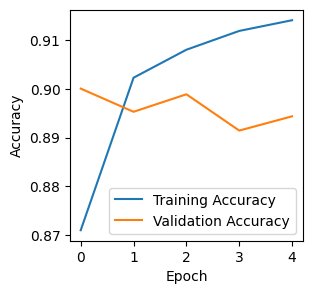

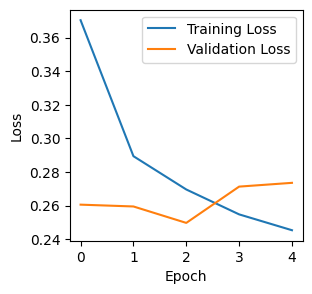

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(3,3))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(3,3))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [27]:
import pandas as pd
predictions_prob = model.predict(X_test_padded)

train_model_df = pd.DataFrame({
    "review_text": X_test_text,  
    "actual_sentiment": y_test,
    "predicted_probability": predictions_prob.flatten(),  
    "predicted_sentiment": predictions.flatten(), 
    "is_correct": (
        y_test == predictions.flatten()
    ),
})


train_model_df.to_csv("C:/Users/shrut/Desktop/PLAYSTORE_NLP/VS_CODE/train_model_df.csv", index=False)

941/941 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step


In [28]:
df2=pd.read_csv("C:/Users/shrut/Desktop/PLAYSTORE_NLP/VS_CODE/train_model_df.csv")

In [34]:
import pandas as pd

print("Predicting on 70k Train Data...")
train_probs = model.predict(X_train_padded)
train_preds = (train_probs > 0.5).astype(int)

trainingdata_model = pd.DataFrame({
    'review_text': X_train_text,
    'actual_sentiment': y_train,
    'predicted_probability': train_probs.flatten(),
    'predicted_sentiment': train_preds.flatten(),
    'split_type': 'Train'
})

Predicting on 70k Train Data...
2195/2195 ━━━━━━━━━━━━━━━━━━━━ 22s 10ms/step


In [35]:
trainingdata_model.to_csv("C:/Users/shrut/Desktop/PLAYSTORE_NLP/VS_CODE/trainingdata_model_df.csv", index=False)

In [36]:
df_full = pd.concat([trainingdata_model, train_model_df], axis=0, ignore_index=True)

df_full['is_correct'] = (df_full['actual_sentiment'] == df_full['predicted_sentiment'])

df_full.to_csv("C:/Users/shrut/Desktop/PLAYSTORE_NLP/final_ml_1lakh.csv", index=False)

In [3]:
df4=pd.read_csv("C:/Users/shrut/Desktop/PLAYSTORE_NLP/final_ml_1lakh.csv")

In [5]:
df4

,review_text,actual_sentiment,predicted_probability,predicted_sentiment,split_type,is_correct
0,i did not even enter the account though i got ...,0,0.016639,0,Train,True
1,regarding amazon pay later why do i get like 1...,0,0.084843,0,Train,True
2,i am very disappointed with instagrams account...,0,0.031222,0,Train,True
3,ive been using phonepe for a while now and i t...,1,0.971562,1,Train,True
4,super useful would recommend i love that i can...,1,0.998780,1,Train,True
...,...,...,...,...,...,...
100297,worst experience ever faced worst customer ser...,0,0.017335,0,NaN,True
100298,hello developers amazing ui ux love this app w...,1,0.997912,1,NaN,True
100299,nykaa delivery service is very poorspecially x...,0,0.015000,0,NaN,True
100300,why every time after payment when you share re...,0,0.223763,0,NaN,True


In [41]:
df4['is_correct'].value_counts()

is_correct
True     91828
False     8474
Name: count, dtype: int64

In [7]:
df4["predicted_sentiment"].value_counts()

predicted_sentiment
0    72973
1    27329
Name: count, dtype: int64

In [6]:
# 1. Median probability for Class 0 (Negative predictions)
median_prob_0 = df4[df4['predicted_sentiment'] == 0][
    'predicted_probability'
].median()

# 2. Median probability for Class 1 (Positive predictions)
median_prob_1 = df4[df4['predicted_sentiment'] == 1][
    'predicted_probability'
].median()

print(f"Median probability for predicting Class 0: {median_prob_0:.4f}")
print(f"Median probability for predicting Class 1: {median_prob_1:.4f}")

Median probability for predicting Class 0: 0.0340
Median probability for predicting Class 1: 0.9822
